## EDA, Data Cleaning & Data Preprocessing: NHANES(National Health And Nutrition Examination Survey) Dataset

### Step 1: EDA, Data Cleaning: Shape, Distribution (anomalies detection), Missing values, Feature correlation analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("NHANES_Comprehensive_Health_Profile.csv")

# 1. Standard Structure Check
print(f"Data Shape: {df.shape}")

# 2. Logic & Distribution Check
print("\n--- Value Distribution Check ---")
display(df[['Feeling_Depressed_Freq']].describe())

print("\n--- Inspecting Unique Values ---")
print(df['Feeling_Depressed_Freq'].value_counts())

Data Shape: (13137, 9)

--- Value Distribution Check ---


,Feeling_Depressed_Freq
count,1.313700e+04
mean,2.307985e-01
std,6.224961e-01
min,0.000000e+00
25%,0.000000e+00
50%,5.400000e-79
75%,5.400000e-79
max,9.000000e+00



--- Inspecting Unique Values ---
Feeling_Depressed_Freq
5.400000e-79    6120
0.000000e+00    4934
1.000000e+00    1439
2.000000e+00     377
3.000000e+00     260
9.000000e+00       5
7.000000e+00       2
Name: count, dtype: int64


In [2]:
# Treat "Feeling_Depressed_Freq" anomalies as 0, ensuring we don't lose ~46% of the dataset by deleting them.
# Rationale:5.39e-79 is a computational artifact representing 0.

df.loc[(df['Feeling_Depressed_Freq'] > 0) & (df['Feeling_Depressed_Freq'] < 1e-4), 'Feeling_Depressed_Freq'] = 0

# Map 7 (Refused) and 9 (Don't Know) to 0 (Mode).
# Rationale: 7 and 9 are non-responses, and treating them as 0 (the most common response) is a common practice in survey data cleaning to preserve data integrity.
df['Feeling_Depressed_Freq'] = df['Feeling_Depressed_Freq'].replace({7: 0, 9: 0})

# Ensure the column is integer type for consistency
df['Feeling_Depressed_Freq'] = df['Feeling_Depressed_Freq'].astype(int)

print("Distribution of 'Feeling_Depressed_Freq' after cleaning:")
print(df['Feeling_Depressed_Freq'].value_counts())

Distribution of 'Feeling_Depressed_Freq' after cleaning:
Feeling_Depressed_Freq
0    11061
1     1439
2      377
3      260
Name: count, dtype: int64


In [3]:
# 3. Standard Missing Value Check
print("\n--- Standard Missing Values (NaNs) ---")
missing_summary = pd.DataFrame({
    "missing_cnt": df.isna().sum(),
    "missing_pct": df.isna().mean()
}).sort_values(by="missing_pct", ascending=False)
display(missing_summary)


--- Standard Missing Values (NaNs) ---


,missing_cnt,missing_pct
Sedentary_Minutes_Per_Day,4363,0.332115
Waist_cm,603,0.045901
User_ID,0,0.000000
Height_cm,0,0.000000
Weight_kg,0,0.000000
BMI,0,0.000000
Feeling_Depressed_Freq,0,0.000000
Sleep_Hours_Weekdays,0,0.000000
Has_Diabetes,0,0.000000


In [4]:
# Fill in missing values in "Sedentary_Minutes_Per_Day" with Median
# Rationale: Use Median Imputation because median is robust against outliers.

cols_to_impute = ['Sedentary_Minutes_Per_Day', 'Waist_cm']

for col in cols_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Imputed missing values in '{col}' with median: {median_val}")

# Final check for any remaining missing values
print("\nTotal missing values remaining in dataset:", df.isnull().sum().sum())

Imputed missing values in 'Sedentary_Minutes_Per_Day' with median: 300.0
Imputed missing values in 'Waist_cm' with median: 91.0

Total missing values remaining in dataset: 0


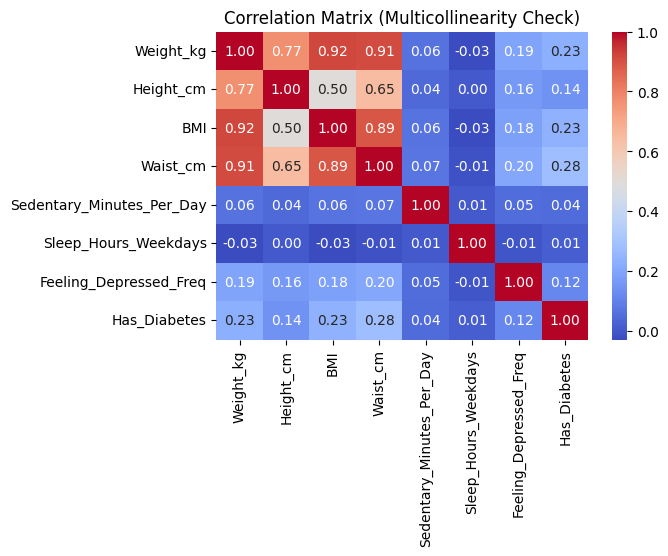

In [5]:
# 4. Feature Correlation Analysis
# Rationale: Detect multicollinearity so that redundant features can be compressed using PCA

plt.figure(figsize=(6,4))

numeric_cols = [
    'Weight_kg', 'Height_cm', 'BMI', 'Waist_cm',
    'Sedentary_Minutes_Per_Day', 'Sleep_Hours_Weekdays',
    'Feeling_Depressed_Freq', 'Has_Diabetes'
]

ax = sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

ax.set_title('Correlation Matrix (Multicollinearity Check)')

plt.show() 

### Step 2: Data Preprocessing: Feature engineering

In this step, we perform feature engineering to flag risks in multiple dimensions (physical, lifestyle, clinical). This ensures the LLM recognizes vulnerable user groups and provides medically appropriate context rather than generic advice.

In [6]:
# 1. Physical Risk
def categorize_risk(row):
    if row['Height_cm'] < 145 and row['Weight_kg'] < 40:
        return 'Potential_Child'   
    elif row['BMI'] > 40:
        return 'High_Risk_Obesity'
    elif row['BMI'] < 16:
        return 'High_Risk_Underweight'
    else:
        return 'Standard_Range'

df['Risk_Category'] = df.apply(categorize_risk, axis=1)

# 2. Lifestyle Risk
# Sedentary > 8 hours (480 mins) is a common WHO risk threshold
df['Lifestyle_Sedentary'] = df['Sedentary_Minutes_Per_Day'] > 480

# Sleep < 6 hours is often considered insufficient
df['Lifestyle_Poor_Sleep'] = df['Sleep_Hours_Weekdays'] < 6

# 3. Clinical Risk
# Depression Freq >= 1 indicates some level of mental distress
df['Clinical_Depression_Flag'] = df['Feeling_Depressed_Freq'] >= 1

# Diabetes is a hard clinical constraint
df['Clinical_Diabetes_Flag'] = df['Has_Diabetes'] == 1

# 4. Verification
print("Risk Category Distribution:")
print(df['Risk_Category'].value_counts())
print("\nPercentage of Users with Additional Risks:")
print(df[['Lifestyle_Sedentary', 'Lifestyle_Poor_Sleep', 'Clinical_Depression_Flag', 'Clinical_Diabetes_Flag']].mean() * 100)

Risk Category Distribution:
Risk_Category
Standard_Range           9857
Potential_Child          2337
High_Risk_Obesity         872
High_Risk_Underweight      71
Name: count, dtype: int64

Percentage of Users with Additional Risks:
Lifestyle_Sedentary         11.989039
Lifestyle_Poor_Sleep         7.299992
Clinical_Depression_Flag    15.802695
Clinical_Diabetes_Flag       9.941387
dtype: float64


### Step 3: Basic Visualization

C:\Users\natal\AppData\Local\Temp\ipykernel_23256\3943784506.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


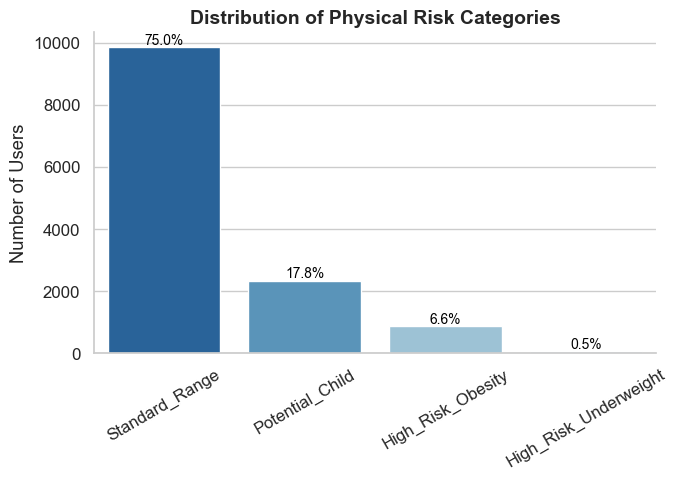

In [7]:
# Set clean theme
sns.set_theme(style="whitegrid", font_scale=1.1)

# Prepare data
order = df['Risk_Category'].value_counts().index
counts = df['Risk_Category'].value_counts()
total = len(df)

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x='Risk_Category',
    order=order,
    palette="Blues_r"
)

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10,
        color='black'
    )

# Styling
plt.title("Distribution of Physical Risk Categories", fontsize=14, weight='bold')
plt.xlabel("")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)
sns.despine()

plt.tight_layout()
plt.show()

C:\Users\natal\AppData\Local\Temp\ipykernel_23256\4097398291.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


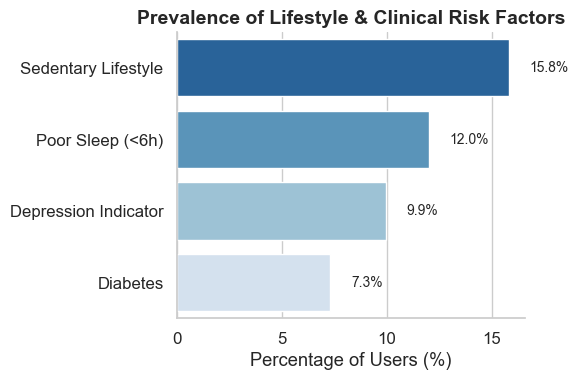

In [8]:
sns.set_theme(style="whitegrid", font_scale=1.1)

risk_flags = [
    'Lifestyle_Sedentary',
    'Lifestyle_Poor_Sleep',
    'Clinical_Depression_Flag',
    'Clinical_Diabetes_Flag'
]

# Calculate percentages
risk_percentages = (df[risk_flags].mean() * 100).sort_values(ascending=False)

# Rename for nicer labels
risk_percentages.index = [
    "Sedentary Lifestyle",
    "Poor Sleep (<6h)",
    "Depression Indicator",
    "Diabetes"
]

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=risk_percentages.values,
    y=risk_percentages.index,
    palette="Blues_r"
)

# Add percentage labels
for i, v in enumerate(risk_percentages.values):
    ax.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=10)

# Styling
plt.title("Prevalence of Lifestyle & Clinical Risk Factors",
          fontsize=14, weight='bold')

plt.xlabel("Percentage of Users (%)")
plt.ylabel("")
sns.despine()

plt.tight_layout()
plt.show()

### Step 4: Standardization & PCA
In this step, we standardize the data to bring all features to a common scale (e.g., preventing 'Weight' in kg from dominating 'Sleep' in hours). We then apply PCA to reduce multicollinearity, compressing redundant physical metrics into independent 'Principal Components' for unbiased clustering.

Explained Variance Ratio per Component:
[0.43581552 0.12855287 0.12475    0.1187123 ]
Total Information Retained: 80.78%


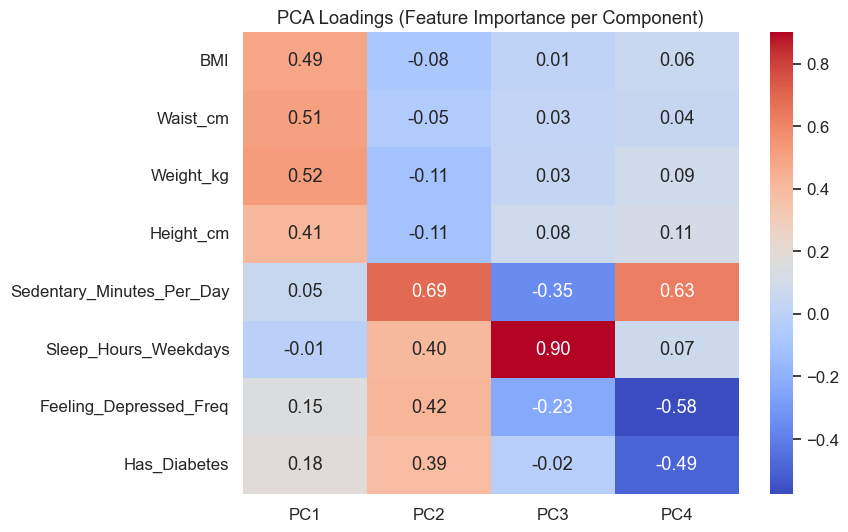

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardization (Z-Score Scaling)
# Rationale: K-Means is sensitive to scale. We must make Mean=0, Std=1 for all features.
features = [
    'BMI', 'Waist_cm', 'Weight_kg', 'Height_cm',           # Physical (Redundant)
    'Sedentary_Minutes_Per_Day', 'Sleep_Hours_Weekdays',   # Lifestyle
    'Feeling_Depressed_Freq', 'Has_Diabetes'               # Clinical
]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# 2. Apply PCA
# We start with n_components=4 to see how much variance they explain
pca = PCA(n_components=4)
pca_data = pca.fit_transform(df_scaled)

# 3. Explained Variance Check
# How much "information" (variance) does each component hold?
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio per Component:")
print(explained_variance)
print(f"Total Information Retained: {sum(explained_variance) * 100:.2f}%")

# 4. Interpret the Components (Loadings)
# This tells us WHAT each component actually represents (e.g., PC1 = Obesity?)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=features
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('PCA Loadings (Feature Importance per Component)')
plt.show()

# Save PCA data for the next step (Clustering)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3', 'PC4'])

Standardization and PCA successfully reduced data dimensionality to 4 components, retaining 80.78% of the total variance. The first component (PC1) accounts for 43.58% of the variance, effectively consolidating the highly correlated physical metrics (BMI, Weight, Waist, Height) into a single 'Body Composition' factor to prevent model bias.